# 02 — Preprocessing

Cleaning, transformation, and scaling. **Keep evidence of what changed at every step** (row counts before/after, before/after distributions) — the rubric explicitly requires this.

Load raw data with `load_raw_data()`, save the result to `../data/processed/airbnb_clean.csv` at the end using `DATA_PROCESSED_PATH` from `utils.py`.

In [1]:
import sys
sys.path.append('../src')
from utils import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load raw data
Reload from `data/raw/` — never edit the raw file.

In [2]:
# ── 1. Load raw data ──────────────────────────────────────────
df = load_raw_data()
print(f"Raw shape: {df.shape}")
df_clean = df.copy()  # never mutate the raw load directly

Raw shape: (48895, 16)


## 3. Handle missing values
reviews_per_month / last_review — decide impute vs. flag-as-new-listing. Justify the choice.

In [ ]:
# ── 3. Handle missing values ────────────────────────────────────
print("Before:")
print(missingness_report(df_clean))


assert (df_clean.loc[df_clean['reviews_per_month'].isna(), 'number_of_reviews'] == 0).all()
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)


df_clean['last_review'] = pd.to_datetime(df_clean['last_review'])

df_clean['name'] = df_clean['name'].fillna('Unknown')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown')

print("\nAfter:")
print(missingness_report(df_clean))

Before:
                   missing_count  missing_pct
reviews_per_month          10052        20.56
last_review                10052        20.56
host_name                     21         0.04
name                          16         0.03

After:
             missing_count  missing_pct
last_review          10052        20.56


## 4. Handle outliers
price == 0 and extreme highs; extreme minimum_nights. Show row counts removed/capped.

In [ ]:

n_before = len(df_clean)


zero_price = (df_clean['price'] == 0).sum()
df_clean = df_clean[df_clean['price'] > 0]


lower, upper = iqr_outlier_bounds(df_clean['price'])
upper = max(upper, 0)  
extreme_high = (df_clean['price'] > upper).sum()
df_clean = df_clean[df_clean['price'] <= upper]

print(f"Dropped price==0: {zero_price} rows")
print(f"Dropped price>{upper:.0f} (IQR upper bound): {extreme_high} rows")


extreme_nights = (df_clean['minimum_nights'] > 365).sum()
df_clean = df_clean[df_clean['minimum_nights'] <= 365]
print(f"Dropped minimum_nights>365: {extreme_nights} rows")

print(f"\nTotal rows: {n_before} → {len(df_clean)} ({n_before - len(df_clean)} removed, "
      f"{(n_before - len(df_clean)) / n_before * 100:.2f}%)")

Dropped price==0: 11 rows
Dropped price>334 (IQR upper bound): 2972 rows
Dropped minimum_nights>365: 13 rows

Total rows: 48895 → 45899 (2996 removed, 6.13%)


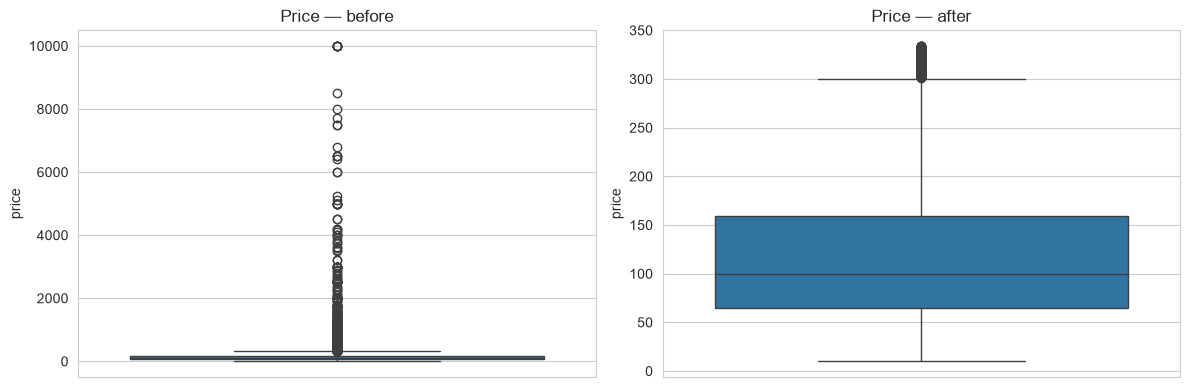

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['price'], ax=axes[0])         
axes[0].set_title('Price — before')
sns.boxplot(y=df_clean['price'], ax=axes[1])  
axes[1].set_title('Price — after')
plt.tight_layout()
plt.savefig('../figures/price_outliers_before_after.png', dpi=150)
plt.show()

## 5. Transform skewed variables
log(price + 1). Show before/after distribution plots.

Price skew before: 0.925
Price skew after log1p: -0.093


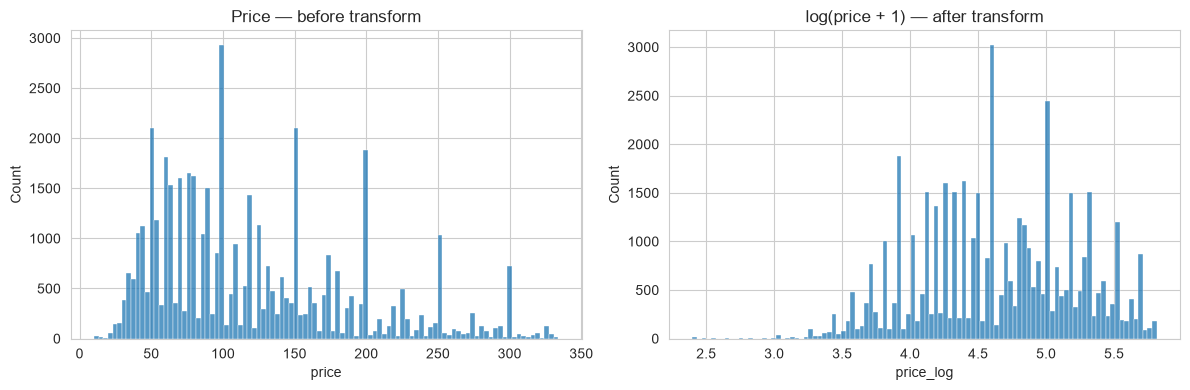

In [ ]:
print(f"Price skew before: {df_clean['price'].skew():.3f}")

df_clean['price_log'] = np.log1p(df_clean['price'])

print(f"Price skew after log1p: {df_clean['price_log'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_clean, x='price', bins=100, ax=axes[0])
axes[0].set_title('Price — before transform')
sns.histplot(data=df_clean, x='price_log', bins=100, ax=axes[1])
axes[1].set_title('log(price + 1) — after transform')
plt.tight_layout()
plt.savefig('../figures/price_transform_before_after.png', dpi=150)
plt.show()

## 6. Scale numeric features
StandardScaler or MinMaxScaler — fit on train only once you split, or document if scaling pre-split for simplicity.

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
                     'calculated_host_listings_count', 'availability_365']

scaler = StandardScaler()
scaled = scaler.fit_transform(df_clean[numeric_features])
scaled_cols = [f"{c}_scaled" for c in numeric_features]
df_clean[scaled_cols] = scaled

print("Scaled columns added:", scaled_cols)
df_clean[scaled_cols].describe()

Scaled columns added: ['minimum_nights_scaled', 'number_of_reviews_scaled', 'reviews_per_month_scaled', 'calculated_host_listings_count_scaled', 'availability_365_scaled']


,minimum_nights_scaled,number_of_reviews_scaled,reviews_per_month_scaled,calculated_host_listings_count_scaled,availability_365_scaled
count,4.589900e+04,4.589900e+04,4.589900e+04,4.589900e+04,4.589900e+04
mean,-1.609979e-17,-3.963026e-17,9.907566e-18,-9.907566e-18,3.467648e-17
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-3.598072e-01,-5.283523e-01,-6.869760e-01,-1.818998e-01,-8.393430e-01
25%,-3.598072e-01,-5.062874e-01,-6.559723e-01,-1.818998e-01,-8.393430e-01
50%,-2.973161e-01,-4.180277e-01,-4.513479e-01,-1.818998e-01,-5.399233e-01
75%,-1.098425e-01,1.205665e-03,3.175436e-01,-1.496581e-01,8.189818e-01
max,2.238698e+01,1.335048e+01,3.558734e+01,1.032889e+01,1.962919e+00


## 7. Save processed data
Write to `../data/processed/airbnb_clean.csv`.

In [9]:
# ── 7. Save processed data ───────────────────────────────────────
df_clean.to_csv(DATA_PROCESSED_PATH, index=False)
print(f"Saved: {DATA_PROCESSED_PATH}")
print(f"Final shape: {df_clean.shape}")

Saved: ../data/processed/airbnb_clean.csv
Final shape: (45899, 22)
